In [16]:
import pandas as pd
import plotly.express as px
from datetime import datetime
import pytz

In [17]:
apps_df = pd.read_csv(r"C:\Users\ashis\OneDrive\Desktop\GooglePlayProject\Play Store Data.csv")

In [18]:
apps_df = apps_df[apps_df['Installs'] != 'Free']
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '')
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '')
apps_df['Installs'] = pd.to_numeric(
    apps_df['Installs'],
    errors='coerce'
)
apps_df = apps_df.dropna(subset=['Installs'])
apps_df['Installs'] = apps_df['Installs'].astype(int)

In [19]:
apps_df = apps_df[apps_df['Installs'] > 1000000]

In [20]:
apps_df = apps_df[~apps_df['Category'].str.startswith(('A', 'C', 'G', 'S'))]

In [21]:
top_categories = apps_df.groupby('Category')['Installs'].sum().reset_index()
top_categories = top_categories.sort_values(
    by='Installs',
    ascending=False
).head(5)
top_categories

,Category,Installs
20,PRODUCTIVITY,14105000000
21,TOOLS,11325000000
19,PHOTOGRAPHY,10025000000
7,FAMILY,9895000000
16,NEWS_AND_MAGAZINES,7435000000


In [22]:
country_map = {
    'PRODUCTIVITY': 'India',
    'TOOLS': 'Russia',
    'PHOTOGRAPHY': 'Japan',
    'FAMILY': 'United States',
    'NEWS_AND_MAGAZINES': 'Nepal'
}

In [23]:
top_categories['Country'] = top_categories['Category'].map(country_map)

In [24]:
top_categories

,Category,Installs,Country
20,PRODUCTIVITY,14105000000,India
21,TOOLS,11325000000,Russia
19,PHOTOGRAPHY,10025000000,Japan
7,FAMILY,9895000000,United States
16,NEWS_AND_MAGAZINES,7435000000,Nepal


C:\Users\ashis\AppData\Local\Temp\ipykernel_21624\3676839161.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig2 = px.choropleth(


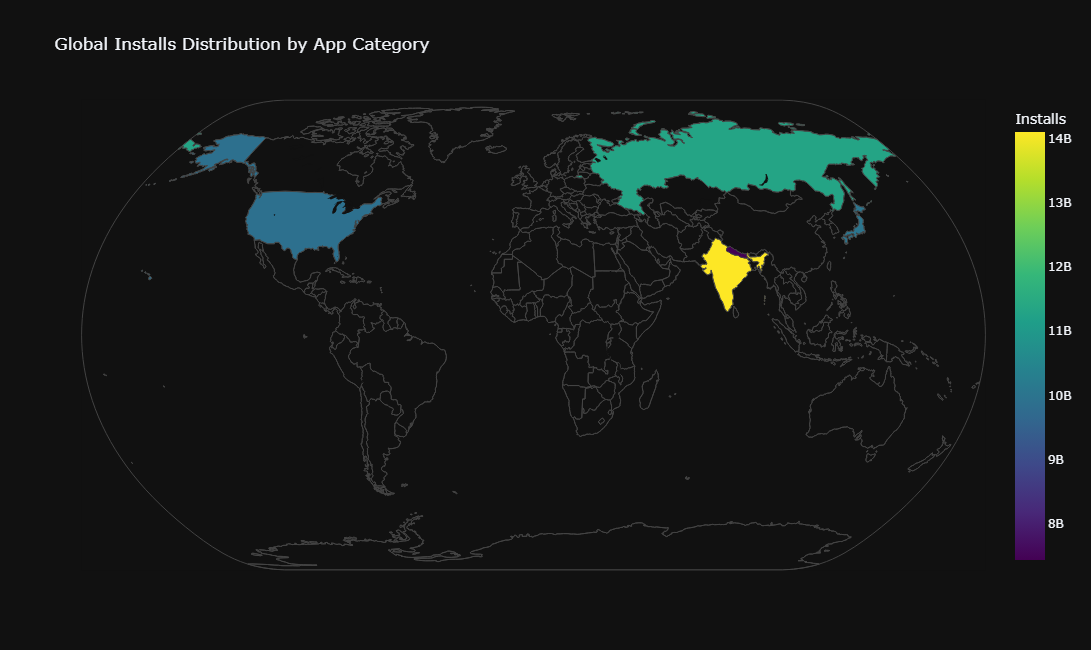

In [27]:
india = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(india)
current_hour = current_time.hour
if True:
    fig2 = px.choropleth(
        top_categories,
        locations='Country',
        locationmode='country names',
        color='Installs',
        hover_name='Category',
        title='Global Installs Distribution by App Category',
        color_continuous_scale='Viridis'
    )
    fig2.update_geos(
        projection_type='natural earth',
        showcountries=True,
        showcoastlines=True,
        showland=True
    )
    fig2.update_layout(
        template='plotly_dark',
        width=1000,
        height=650
    )
    fig2.show()
else:
    print("Graph available only between 6 PM IST and 8 PM IST")